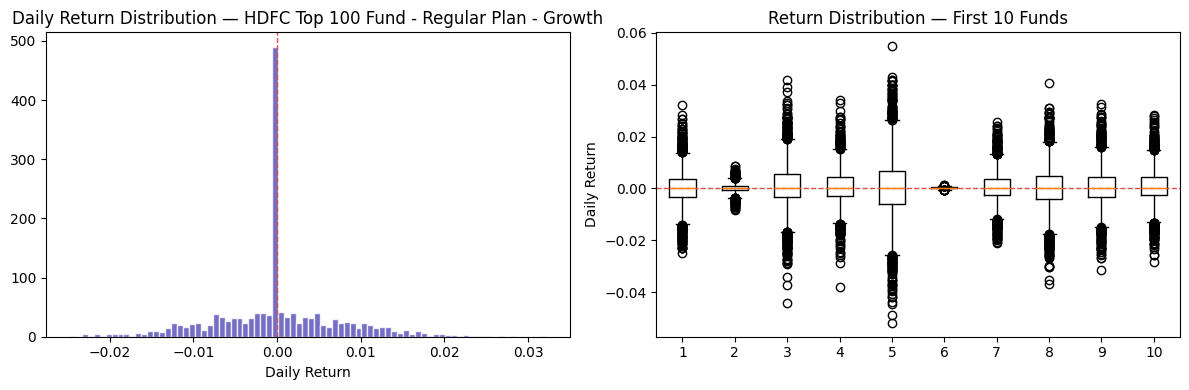

✅ Saved: ../reports/charts/10_daily_return_dist.png
Total return rows: 64,280


,count,mean,std,min,25%,50%,75%,max
scheme_name,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1607.0,0.0006,0.0078,-0.0381,-0.0028,0.0000,0.0044,0.0340
ABSL Liquid Fund - Regular - Growth,1607.0,0.0002,0.0003,-0.0008,0.0000,0.0001,0.0004,0.0012
ABSL Small Cap Fund - Regular - Growth,1607.0,0.0003,0.0137,-0.0518,-0.0062,0.0000,0.0069,0.0549
Axis Bluechip Fund - Direct - Growth,1607.0,0.0002,0.0074,-0.0295,-0.0032,0.0000,0.0039,0.0306
Axis Bluechip Fund - Regular - Growth,1607.0,0.0002,0.0074,-0.0234,-0.0030,0.0000,0.0036,0.0336
Axis Midcap Fund - Regular - Growth,1607.0,0.0007,0.0103,-0.0408,-0.0039,0.0000,0.0055,0.0416
Axis Small Cap Fund - Regular - Growth,1607.0,0.0001,0.0134,-0.0484,-0.0060,0.0000,0.0057,0.0431
DSP Midcap Fund - Regular - Growth,1607.0,0.0008,0.0095,-0.0301,-0.0033,0.0000,0.0057,0.0420
DSP Small Cap Fund - Regular - Growth,1607.0,0.0009,0.0132,-0.0489,-0.0051,0.0000,0.0070,0.0485


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from pathlib import Path

# Create output folder
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

# Database connection
engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

# Load NAV data
nav = pd.read_sql("""
    SELECT
        n.amfi_code,
        n.date_id,
        n.nav,
        f.scheme_name
    FROM fact_nav n
    JOIN dim_fund f
        ON n.amfi_code = f.amfi_code
    ORDER BY n.amfi_code, n.date_id
""", engine)

nav["date_id"] = pd.to_datetime(nav["date_id"])

# Calculate daily returns scheme-wise
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav = nav.dropna(subset=["daily_return"])

# Sample fund for histogram
sample_code = nav["amfi_code"].iloc[0]
sample_name = (
    nav.loc[nav["amfi_code"] == sample_code, "scheme_name"]
    .iloc[0]
)

sample = nav.loc[
    nav["amfi_code"] == sample_code,
    "daily_return"
]

# Charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(
    sample,
    bins=80,
    color="#534AB7",
    alpha=0.8,
    edgecolor="white"
)

axes[0].axvline(
    0,
    color="#E24B4A",
    linestyle="--",
    linewidth=1
)

axes[0].set_title(
    f"Daily Return Distribution — {sample_name}"
)

axes[0].set_xlabel("Daily Return")

# Boxplots for first 10 schemes
fund_codes = nav["amfi_code"].unique()[:10]

box_data = [
    nav.loc[
        nav["amfi_code"] == code,
        "daily_return"
    ]
    for code in fund_codes
]

axes[1].boxplot(box_data)

axes[1].axhline(
    0,
    color="#E24B4A",
    linestyle="--",
    linewidth=1
)

axes[1].set_title(
    "Return Distribution — First 10 Funds"
)

axes[1].set_ylabel("Daily Return")

plt.tight_layout()

plt.savefig(
    "../reports/charts/10_daily_return_dist.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved: ../reports/charts/10_daily_return_dist.png")
print(f"Total return rows: {len(nav):,}")

display(
    nav.groupby("scheme_name")["daily_return"]
       .describe()
       .round(4)
)

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

def compute_cagr(group, years):

    latest_date = group["date_id"].max()
    start_date = latest_date - pd.DateOffset(years=years)

    start_rows = group[group["date_id"] >= start_date]

    if start_rows.empty:
        return np.nan

    actual_start = start_rows["date_id"].min()

    if (latest_date - actual_start).days < years * 365 * 0.90:
        return np.nan

    start_nav = start_rows.iloc[0]["nav"]
    end_nav = group.loc[
        group["date_id"] == latest_date,
        "nav"
    ].iloc[0]

    return (end_nav / start_nav) ** (1 / years) - 1

results = []

for code, grp in nav.groupby("amfi_code"):

    results.append({
        "amfi_code": code,
        "scheme_name": grp["scheme_name"].iloc[0],
        "cagr_1yr": compute_cagr(grp, 1),
        "cagr_3yr": compute_cagr(grp, 3),
        "cagr_5yr": compute_cagr(grp, 5)
    })

cagr_df = pd.DataFrame(results)

cagr_df[["cagr_1yr", "cagr_3yr", "cagr_5yr"]] *= 100

cagr_df = cagr_df.sort_values(
    "cagr_3yr",
    ascending=False
)

print(
    cagr_df[
        ["scheme_name",
         "cagr_1yr",
         "cagr_3yr",
         "cagr_5yr"]
    ].round(2).to_string(index=False)
)

cagr_df.to_csv(
    "../data/processed/cagr_table.csv",
    index=False
)

print(
    "\n✅ Saved: ../data/processed/cagr_table.csv"
)

                                          scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
                  Axis Midcap Fund - Regular - Growth     22.26     35.11       NaN
        Mirae Asset Large Cap Fund - Regular - Growth     20.36     34.00       NaN
            ICICI Pru Bluechip Fund - Direct - Growth     13.06     32.49       NaN
   HDFC Mid-Cap Opportunities Fund - Regular - Growth     53.23     32.44       NaN
             ICICI Pru Midcap Fund - Regular - Growth     29.60     31.78       NaN
            SBI Bluechip Fund - Regular Plan - Growth     60.44     30.46       NaN
               Kotak Flexicap Fund - Regular - Growth     26.66     29.58       NaN
        Mirae Asset Tax Saver Fund - Regular - Growth     39.75     29.18       NaN
        ABSL Frontline Equity Fund - Regular - Growth     47.92     28.97       NaN
                DSP Small Cap Fund - Regular - Growth     65.14     27.00       NaN
                   DSP Midcap Fund - Regular - Growth     21.48     26.87   

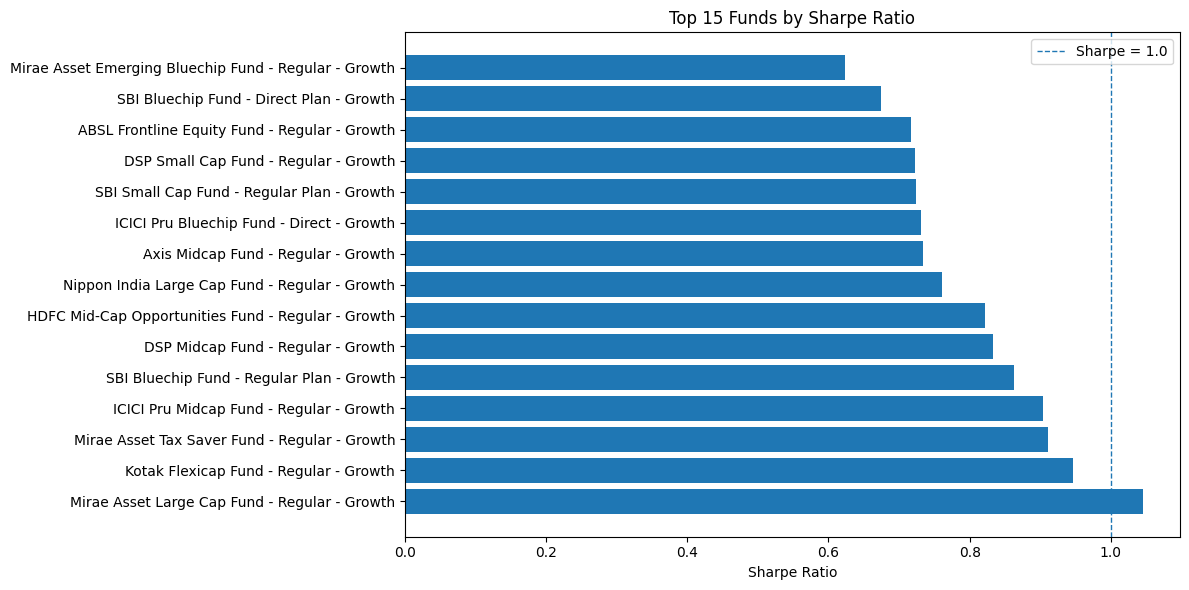

                                       scheme_name  sharpe_ratio  sharpe_rank
     Mirae Asset Large Cap Fund - Regular - Growth        1.0456            1
            Kotak Flexicap Fund - Regular - Growth        0.9462            2
     Mirae Asset Tax Saver Fund - Regular - Growth        0.9110            3
          ICICI Pru Midcap Fund - Regular - Growth        0.9040            4
         SBI Bluechip Fund - Regular Plan - Growth        0.8625            5
                DSP Midcap Fund - Regular - Growth        0.8329            6
HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.8223            7
    Nippon India Large Cap Fund - Regular - Growth        0.7604            8
               Axis Midcap Fund - Regular - Growth        0.7345            9
         ICICI Pru Bluechip Fund - Direct - Growth        0.7306           10

✅ Saved: ../reports/charts/11_sharpe_ranking.png
✅ Saved: ../data/processed/sharpe_ranking.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Risk-Free Rate Assumption
# =====================================

RF_ANNUAL = 0.065      # 6.5%
RF_DAILY = RF_ANNUAL / 252
TRADING_DAYS = 252

# =====================================
# Create Daily Returns
# =====================================

nav = nav.sort_values(["amfi_code", "date_id"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav = nav.dropna(subset=["daily_return"])

# =====================================
# Sharpe Calculation
# =====================================

sharpe_results = []

for code, grp in nav.groupby("amfi_code"):

    r = grp["daily_return"]

    mean_daily_return = r.mean()
    std_daily_return = r.std()

    excess_return = mean_daily_return - RF_DAILY

    sharpe = (
        (excess_return / std_daily_return)
        * np.sqrt(TRADING_DAYS)
        if std_daily_return > 0
        else np.nan
    )

    sharpe_results.append({
        "amfi_code": code,
        "scheme_name": grp["scheme_name"].iloc[0],
        "ann_return": mean_daily_return * TRADING_DAYS * 100,
        "ann_std": std_daily_return * np.sqrt(TRADING_DAYS) * 100,
        "sharpe_ratio": round(sharpe, 4)
    })

# =====================================
# Ranking
# =====================================

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["sharpe_rank"] = sharpe_df.index + 1

# =====================================
# Top 15 Chart
# =====================================

top15 = sharpe_df.head(15)

plt.figure(figsize=(12, 6))

plt.barh(
    top15["scheme_name"],
    top15["sharpe_ratio"]
)

plt.axvline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Sharpe = 1.0"
)

plt.title("Top 15 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/11_sharpe_ranking.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# =====================================
# Output
# =====================================

print(
    sharpe_df[
        ["scheme_name", "sharpe_ratio", "sharpe_rank"]
    ]
    .head(10)
    .to_string(index=False)
)

# Optional save
sharpe_df.to_csv(
    "../data/processed/sharpe_ranking.csv",
    index=False
)

print("\n✅ Saved: ../reports/charts/11_sharpe_ranking.png")
print("✅ Saved: ../data/processed/sharpe_ranking.csv")

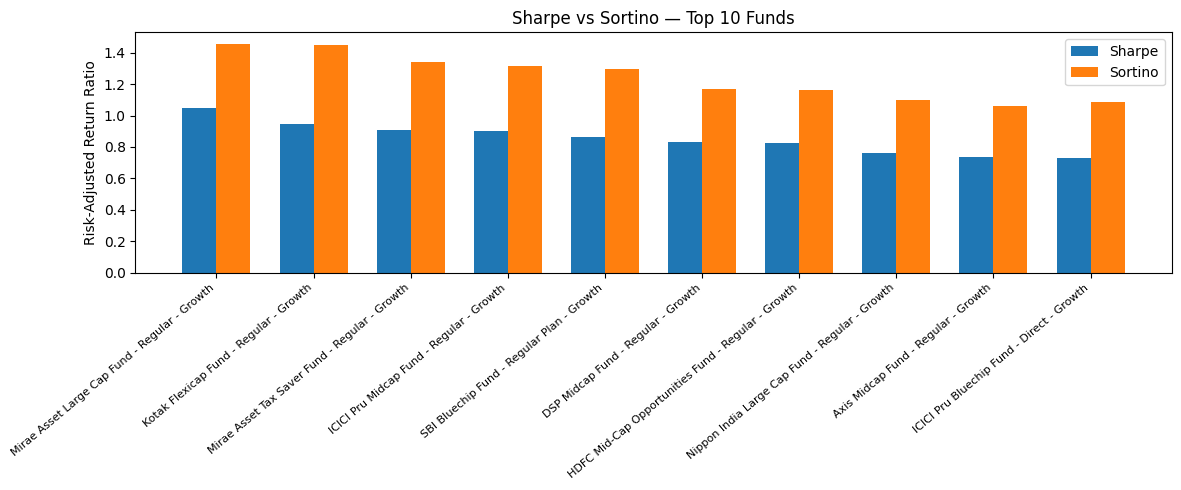

                                       scheme_name  sortino_ratio  sortino_rank
     Mirae Asset Large Cap Fund - Regular - Growth         1.4570             1
            Kotak Flexicap Fund - Regular - Growth         1.4484             2
     Mirae Asset Tax Saver Fund - Regular - Growth         1.3411             3
          ICICI Pru Midcap Fund - Regular - Growth         1.3165             4
         SBI Bluechip Fund - Regular Plan - Growth         1.2948             5
                DSP Midcap Fund - Regular - Growth         1.1682             6
HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.1631             7
    Nippon India Large Cap Fund - Regular - Growth         1.1018             8
         ICICI Pru Bluechip Fund - Direct - Growth         1.0868             9
        SBI Small Cap Fund - Regular Plan - Growth         1.0836            10

✅ Saved: ../reports/charts/12_sharpe_vs_sortino.png
✅ Saved: ../data/processed/sortino_ranking.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Sortino Ratio Calculation
# =====================================

sortino_results = []

for code, grp in nav.groupby("amfi_code"):

    r = grp["daily_return"]

    downside = r[r < 0]
    downside_std = downside.std()

    excess_return = r.mean() - RF_DAILY

    if pd.notna(downside_std) and downside_std > 0:
        sortino = (
            excess_return /
            downside_std
        ) * np.sqrt(TRADING_DAYS)
    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": code,
        "scheme_name": grp["scheme_name"].iloc[0],
        "sortino_ratio": round(sortino, 4) if pd.notna(sortino) else np.nan,
        "downside_std": (
            round(
                downside_std *
                np.sqrt(TRADING_DAYS) *
                100,
                4
            )
            if pd.notna(downside_std)
            else np.nan
        )
    })

# =====================================
# Ranking
# =====================================

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["sortino_rank"] = (
    sortino_df.index + 1
)

# =====================================
# Compare Sharpe vs Sortino
# =====================================

top10_sharpe = sharpe_df.head(10)

merged = top10_sharpe.merge(
    sortino_df[
        ["scheme_name", "sortino_ratio"]
    ],
    on="scheme_name"
)

# =====================================
# Visualization
# =====================================

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(merged))
width = 0.35

ax.bar(
    x - width/2,
    merged["sharpe_ratio"],
    width,
    label="Sharpe"
)

ax.bar(
    x + width/2,
    merged["sortino_ratio"],
    width,
    label="Sortino"
)

ax.set_xticks(x)

ax.set_xticklabels(
    merged["scheme_name"],
    rotation=40,
    ha="right",
    fontsize=8
)

ax.set_title(
    "Sharpe vs Sortino — Top 10 Funds"
)

ax.set_ylabel(
    "Risk-Adjusted Return Ratio"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/12_sharpe_vs_sortino.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# =====================================
# Output
# =====================================

print(
    sortino_df[
        ["scheme_name",
         "sortino_ratio",
         "sortino_rank"]
    ]
    .head(10)
    .to_string(index=False)
)

sortino_df.to_csv(
    "../data/processed/sortino_ranking.csv",
    index=False
)

print("\n✅ Saved: ../reports/charts/12_sharpe_vs_sortino.png")
print("✅ Saved: ../data/processed/sortino_ranking.csv")

In [3]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from pathlib import Path

# ==========================================
# CONFIG
# ==========================================

TRADING_DAYS = 252

# Database path (running from notebooks folder)
engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

# ==========================================
# LOAD NAV DATA
# ==========================================

nav = pd.read_sql("""
SELECT
    n.amfi_code,
    n.date_id,
    n.nav,
    f.scheme_name
FROM fact_nav n
JOIN dim_fund f
ON n.amfi_code = f.amfi_code
ORDER BY n.amfi_code, n.date_id
""", engine)

nav["date_id"] = pd.to_datetime(nav["date_id"])

# Daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav = nav.dropna(subset=["daily_return"])

print(f"Loaded NAV rows: {len(nav):,}")

# ==========================================
# LOAD BENCHMARK
# ==========================================

bench = pd.read_csv("../data/raw/10_benchmark_indices.csv")

bench["date"] = pd.to_datetime(bench["date"])

print("\nAvailable Benchmarks:")
print(bench["index_name"].unique())

# Use NIFTY50
bench = (
    bench[bench["index_name"] == "NIFTY50"]
    .sort_values("date")
)

bench["bench_return"] = (
    bench["close_value"]
    .pct_change()
)

bench = bench.dropna(subset=["bench_return"])

print(f"Benchmark rows: {len(bench):,}")

# ==========================================
# ALPHA / BETA
# ==========================================

results = []

for code, grp in nav.groupby("amfi_code"):

    merged = grp[
        ["date_id", "daily_return"]
    ].merge(
        bench[
            ["date", "bench_return"]
        ],
        left_on="date_id",
        right_on="date",
        how="inner"
    )

    if len(merged) < 60:
        continue

    fund_ret = merged["daily_return"]
    bench_ret = merged["bench_return"]

    # Beta
    beta = np.cov(
        fund_ret,
        bench_ret
    )[0, 1] / np.var(bench_ret)

    # Alpha
    alpha_daily = (
        fund_ret.mean()
        - beta * bench_ret.mean()
    )

    alpha_annual = alpha_daily * TRADING_DAYS * 100

    # R-squared
    corr = np.corrcoef(
        fund_ret,
        bench_ret
    )[0, 1]

    r_squared = corr ** 2

    results.append({
        "amfi_code": code,
        "scheme_name": grp["scheme_name"].iloc[0],
        "alpha_annual": round(alpha_annual, 4),
        "beta": round(beta, 4),
        "r_squared": round(r_squared, 4)
    })

# ==========================================
# RESULTS
# ==========================================

ab_df = pd.DataFrame(results)

ab_df = (
    ab_df
    .sort_values(
        "alpha_annual",
        ascending=False
    )
    .reset_index(drop=True)
)

ab_df["alpha_rank"] = (
    ab_df.index + 1
)

# ==========================================
# SAVE
# ==========================================

Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

ab_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

# ==========================================
# DISPLAY
# ==========================================

print("\nTop 10 Funds By Alpha\n")

print(
    ab_df[
        [
            "scheme_name",
            "alpha_annual",
            "beta",
            "r_squared",
            "alpha_rank"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

print("\n✅ Saved: ../data/processed/alpha_beta.csv")

Loaded NAV rows: 64,280

Available Benchmarks:
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']
Benchmark rows: 1,149

Top 10 Funds By Alpha

                                       scheme_name  alpha_annual    beta  r_squared  alpha_rank
        SBI Small Cap Fund - Regular Plan - Growth       30.1113  0.0743     0.0014           1
             DSP Small Cap Fund - Regular - Growth       29.8176  0.1327     0.0047           2
          ICICI Pru Midcap Fund - Regular - Growth       29.3014 -0.0174     0.0001           3
     Mirae Asset Tax Saver Fund - Regular - Growth       28.3474 -0.0102     0.0001           4
            Kotak Flexicap Fund - Regular - Growth       27.2784 -0.0087     0.0001           5
HDFC Mid-Cap Opportunities Fund - Regular - Growth       27.2343 -0.0112     0.0001           6
     Mirae Asset Large Cap Fund - Regular - Growth       27.1151 -0.0282     0.0007           7
                DSP Midcap Fund - Regular

In [4]:
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

# Create output folder
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

# ==========================================
# Maximum Drawdown Calculation
# ==========================================

mdd_results = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date_id").copy()

    grp["running_max"] = grp["nav"].cummax()
    grp["drawdown"] = grp["nav"] / grp["running_max"] - 1

    mdd_val = grp["drawdown"].min()

    mdd_idx = grp["drawdown"].idxmin()
    mdd_date = grp.loc[mdd_idx, "date_id"]

    before_trough = grp[grp["date_id"] <= mdd_date]

    peak_date = (
        before_trough.loc[
            before_trough["running_max"] == before_trough["nav"],
            "date_id"
        ].max()
    )

    mdd_results.append({
        "amfi_code": code,
        "scheme_name": grp["scheme_name"].iloc[0],
        "max_drawdown": round(mdd_val * 100, 2),
        "peak_date": peak_date.date(),
        "trough_date": mdd_date.date(),
        "recovery_days": (mdd_date - peak_date).days
    })

mdd_df = (
    pd.DataFrame(mdd_results)
    .sort_values("max_drawdown")
)

# ==========================================
# Drawdown Chart for Top Alpha Funds
# ==========================================

top5_codes = (
    ab_df
    .sort_values("alpha_annual", ascending=False)
    ["amfi_code"]
    .head(5)
    .tolist()
)

fig = go.Figure()

for code in top5_codes:

    grp = (
        nav[nav["amfi_code"] == code]
        .sort_values("date_id")
        .copy()
    )

    grp["running_max"] = grp["nav"].cummax()

    grp["drawdown"] = (
        grp["nav"] /
        grp["running_max"] - 1
    ) * 100

    name = grp["scheme_name"].iloc[0]

    fig.add_trace(
        go.Scatter(
            x=grp["date_id"].astype(str),   # avoids timestamp serialization issues
            y=grp["drawdown"],
            mode="lines",
            name=name,
            fill="tozeroy",
            line=dict(width=1.5)
        )
    )

fig.update_layout(
    title="Maximum Drawdown - Top 5 Alpha Funds",
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    hovermode="x unified",
    height=500
)

# Save chart
fig.write_image(
    "../reports/charts/13_drawdown_chart.png",
    scale=2
)

print("✅ Saved: ../reports/charts/13_drawdown_chart.png")

# Display top drawdowns
print("\nTop 10 Drawdowns\n")

print(
    mdd_df[
        [
            "scheme_name",
            "max_drawdown",
            "peak_date",
            "trough_date",
            "recovery_days"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

# Save results table
mdd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("\n✅ Saved: ../data/processed/max_drawdown.csv")

✅ Saved: ../reports/charts/13_drawdown_chart.png

Top 10 Drawdowns

                                   scheme_name  max_drawdown  peak_date trough_date  recovery_days
     SBI Small Cap Fund - Direct Plan - Growth        -52.57 2023-01-17  2025-10-28           1015
        Axis Small Cap Fund - Regular - Growth        -51.68 2025-05-22  2026-05-11            354
        ABSL Small Cap Fund - Regular - Growth        -35.45 2024-11-21  2026-05-11            536
         DSP Small Cap Fund - Regular - Growth        -31.17 2024-05-05  2025-01-03            243
    SBI Small Cap Fund - Regular Plan - Growth        -28.71 2024-08-28  2025-05-14            259
           UTI Mid Cap Fund - Regular - Growth        -28.00 2025-01-07  2026-04-27            475
     HDFC Top 100 Fund - Regular Plan - Growth        -24.73 2022-03-30  2022-09-15            169
 Kotak Emerging Equity Fund - Regular - Growth        -24.00 2023-11-09  2024-10-17            343
Nippon India Small Cap Fund - Regular - G

✅ Saved: ../data/processed/fund_scorecard.csv


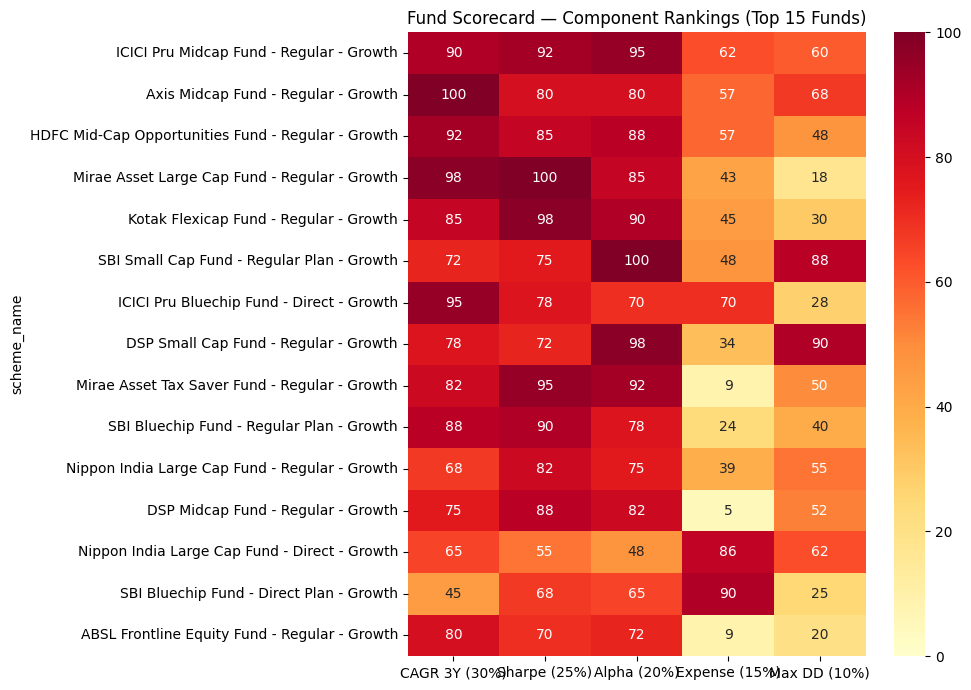


TOP 10 FUNDS
 rank                                        scheme_name  score
    1           ICICI Pru Midcap Fund - Regular - Growth  84.50
    2                Axis Midcap Fund - Regular - Growth  81.38
    3 HDFC Mid-Cap Opportunities Fund - Regular - Growth  79.88
    4      Mirae Asset Large Cap Fund - Regular - Growth  79.38
    5             Kotak Flexicap Fund - Regular - Growth  77.62
    6         SBI Small Cap Fund - Regular Plan - Growth  76.38
    7          ICICI Pru Bluechip Fund - Direct - Growth  75.12
    8              DSP Small Cap Fund - Regular - Growth  74.94
    9      Mirae Asset Tax Saver Fund - Regular - Growth  73.31
   10          SBI Bluechip Fund - Regular Plan - Growth  71.81

✅ Saved: ../reports/charts/14_fund_scorecard_heatmap.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from pathlib import Path

# ==========================================
# LOAD FILES
# ==========================================

cagr_df = pd.read_csv("../data/processed/cagr_table.csv")
ab_df = pd.read_csv("../data/processed/alpha_beta.csv")
sharpe_df = pd.read_csv("../data/processed/sharpe_ranking.csv")
sortino_df = pd.read_csv("../data/processed/sortino_ranking.csv")
mdd_df = pd.read_csv("../data/processed/max_drawdown.csv")

# ==========================================
# DATABASE CONNECTION
# ==========================================

engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

# ==========================================
# EXPENSE RATIO
# ==========================================

exp = pd.read_sql("""
SELECT
    amfi_code,
    expense_ratio_pct AS expense_ratio
FROM fact_performance
""", engine)

# ==========================================
# MASTER SCORECARD
# ==========================================

master = cagr_df[
    ["amfi_code", "scheme_name", "cagr_3yr"]
].copy()

master = master.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code",
    how="inner"
)

master = master.merge(
    sortino_df[["amfi_code", "sortino_ratio"]],
    on="amfi_code",
    how="inner"
)

master = master.merge(
    ab_df[["amfi_code", "alpha_annual", "beta"]],
    on="amfi_code",
    how="inner"
)

master = master.merge(
    mdd_df[["amfi_code", "max_drawdown"]],
    on="amfi_code",
    how="inner"
)

master = master.merge(
    exp,
    on="amfi_code",
    how="left"
)

# ==========================================
# PERCENTILE RANKS
# ==========================================

master["r_cagr3"] = master["cagr_3yr"].rank(pct=True) * 100

master["r_sharpe"] = (
    master["sharpe_ratio"]
    .rank(pct=True) * 100
)

master["r_alpha"] = (
    master["alpha_annual"]
    .rank(pct=True) * 100
)

# Lower expense ratio is better
master["r_exp"] = (
    1 - master["expense_ratio"].rank(pct=True)
) * 100

# Less negative drawdown is better
master["r_mdd"] = (
    1 - master["max_drawdown"].rank(pct=True)
) * 100

# ==========================================
# WEIGHTED SCORE
# ==========================================

master["score"] = (
      0.30 * master["r_cagr3"]
    + 0.25 * master["r_sharpe"]
    + 0.20 * master["r_alpha"]
    + 0.15 * master["r_exp"]
    + 0.10 * master["r_mdd"]
).round(2)

master = master.sort_values(
    "score",
    ascending=False
)

master["rank"] = range(
    1,
    len(master) + 1
)

# ==========================================
# SAVE SCORECARD
# ==========================================

Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

master.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("✅ Saved: ../data/processed/fund_scorecard.csv")

# ==========================================
# TOP 15 HEATMAP
# ==========================================

top15 = master.head(15).set_index(
    "scheme_name"
)

score_cols = [
    "r_cagr3",
    "r_sharpe",
    "r_alpha",
    "r_exp",
    "r_mdd"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    top15[score_cols],
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    xticklabels=[
        "CAGR 3Y (30%)",
        "Sharpe (25%)",
        "Alpha (20%)",
        "Expense (15%)",
        "Max DD (10%)"
    ]
)

plt.title(
    "Fund Scorecard — Component Rankings (Top 15 Funds)"
)

plt.tight_layout()

Path("../reports/charts").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "../reports/charts/14_fund_scorecard_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nTOP 10 FUNDS")
print(
    master[
        ["rank", "scheme_name", "score"]
    ]
    .head(10)
    .to_string(index=False)
)

print("\n✅ Saved: ../reports/charts/14_fund_scorecard_heatmap.png")

In [11]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path

# =====================================
# LOAD NAV DATA
# =====================================

nav = pd.read_sql("""
SELECT
    n.amfi_code,
    n.date_id,
    n.nav,
    f.scheme_name
FROM fact_nav n
JOIN dim_fund f
ON n.amfi_code = f.amfi_code
""", engine)

nav["date_id"] = pd.to_datetime(nav["date_id"])

nav = nav.sort_values(["amfi_code", "date_id"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# =====================================
# LOAD BENCHMARK
# =====================================

bench_all = pd.read_csv("../data/raw/10_benchmark_indices.csv")

bench_all["date"] = pd.to_datetime(
    bench_all["date"]
)

# =====================================
# TOP 5 FUNDS
# =====================================

top5_codes = master.head(5)["amfi_code"].tolist()

start_date = (
    pd.Timestamp.today()
    - pd.DateOffset(years=3)
)

fig = go.Figure()

tracking_errors = []

colors = [
    "#534AB7",
    "#3C3489",
    "#7F77DD",
    "#1D9E75",
    "#0F6E56"
]

# =====================================
# NIFTY50 BENCHMARK
# =====================================

benchmark = (
    bench_all[
        bench_all["index_name"]
        .str.upper()
        .str.contains("NIFTY50")
    ]
    .copy()
)

benchmark = benchmark.sort_values("date")

benchmark["bench_return"] = (
    benchmark["close_value"]
    .pct_change()
)

# =====================================
# FUND LINES
# =====================================

for code, color in zip(top5_codes, colors):

    fund = nav[
        (nav["amfi_code"] == code)
        &
        (nav["date_id"] >= start_date)
    ].copy()

    if len(fund) == 0:
        continue

    fund = fund.sort_values("date_id")

    scheme_name = fund["scheme_name"].iloc[0]

    base_nav = fund["nav"].iloc[0]

    fund["indexed"] = (
        fund["nav"] / base_nav * 100
    )

    fig.add_trace(
        go.Scatter(
            x=fund["date_id"],
            y=fund["indexed"],
            mode="lines",
            name=scheme_name[:30],
            line=dict(
                color=color,
                width=1.8
            )
        )
    )

    merged = fund[
        ["date_id", "daily_return"]
    ].merge(
        benchmark[
            ["date", "bench_return"]
        ],
        left_on="date_id",
        right_on="date",
        how="inner"
    )

    if len(merged) > 50:

        te = (
            (merged["daily_return"]
            - merged["bench_return"])
            .std()
            * np.sqrt(252)
            * 100
        )

        tracking_errors.append({
            "fund": scheme_name,
            "tracking_error_pct": round(te, 2)
        })

# =====================================
# BENCHMARK LINE
# =====================================

benchmark_3yr = benchmark[
    benchmark["date"] >= start_date
].copy()

base_idx = benchmark_3yr["close_value"].iloc[0]

benchmark_3yr["indexed"] = (
    benchmark_3yr["close_value"]
    / base_idx
    * 100
)

fig.add_trace(
    go.Scatter(
        x=benchmark_3yr["date"],
        y=benchmark_3yr["indexed"],
        mode="lines",
        name="NIFTY50",
        line=dict(
            color="#E24B4A",
            width=3,
            dash="dash"
        )
    )
)

# =====================================
# LAYOUT
# =====================================

fig.update_layout(
    title="Top 5 Funds vs NIFTY50 (Indexed to 100)",
    xaxis_title="Date",
    yaxis_title="Indexed Performance (Base=100)",
    hovermode="x unified",
    height=550
)

# =====================================
# SAVE
# =====================================

Path("../reports/charts").mkdir(
    parents=True,
    exist_ok=True
)

fig.write_image(
    "../reports/charts/15_benchmark_comparison.png",
    scale=2
)

print(
    "✅ Saved: ../reports/charts/15_benchmark_comparison.png"
)

# Avoid nbformat error
# fig.show()

te_df = pd.DataFrame(
    tracking_errors
)

print("\nTracking Errors")
print(te_df.to_string(index=False))

✅ Saved: ../reports/charts/15_benchmark_comparison.png

Tracking Errors
                                              fund  tracking_error_pct
          ICICI Pru Midcap Fund - Regular - Growth              487.25
               Axis Midcap Fund - Regular - Growth              487.47
HDFC Mid-Cap Opportunities Fund - Regular - Growth              486.57
     Mirae Asset Large Cap Fund - Regular - Growth              486.69
            Kotak Flexicap Fund - Regular - Growth              486.96
